# ExRec Logical Error Distribution

Syndrome-conditioned logical error analysis for the `[[5,1,3]]` code.

**Circuit model (simplified exRec):**

```
Q_{s_in} · E_fault ──► EC (with syndrome noise) ──► (L, s_out)
```

- `s_in` — input syndrome carried from previous circuitry
- `E_fault` — accumulated Pauli error on the data qubits
- `syndrome_error` — classical bit-flip noise on the measured syndrome
- `L` — resulting logical error class {I, X, Y, Z}
- `s_out` — output syndrome

**Two Monte Carlo models are compared:**
1. **Original MC** — 3 fault locations with depolarizing noise, using the full exRec circuit
2. **New MC** — 2 depolarizing Paulis multiplied into a single fault path, plus independent syndrome bit-flip noise (rate `q`)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pauli_utils import (
    LOGICAL_NAMES,
    pauli_str, str_to_pauli, pauli_weight, all_n_qubit_paulis,
    gate_identity, gate_hadamard, gate_phase_S, gate_phase_Sdg, make_custom_gate,
)
from StabilizerCode import StabilizerCode


## 1. Code Definition

In [3]:

code_513 = StabilizerCode(
    n=5,
    generators=[
        (np.array([1,0,0,1,0]), np.array([0,1,1,0,0])),  # g1: XZZXI
        (np.array([0,1,0,0,1]), np.array([0,0,1,1,0])),  # g2: IXZZX
        (np.array([1,0,1,0,0]), np.array([0,0,0,1,1])),  # g3: XIXZZ
        (np.array([0,1,0,1,0]), np.array([1,0,0,0,1])),  # g4: ZXIXZ
    ],
    logical_x=(np.array([1,1,1,1,1]), np.array([0,0,0,0,0])),  # XXXXX
    logical_z=(np.array([0,0,0,0,0]), np.array([1,1,1,1,1])),  # ZZZZZ
    name='[[5,1,3]]',
)

code_713 = StabilizerCode(
    n = 7,
    generators = [
        (np.array([1,1,1,1,0,0,0]), np.array([0,0,0,0,0,0,0])), # g1: XXXXIII
        (np.array([1,1,0,0,1,1,0]), np.array([0,0,0,0,0,0,0])), # g2: XXIIXX I
        (np.array([1,0,1,0,1,0,1]), np.array([0,0,0,0,0,0,0])), # g3: XIXIXIX
        (np.array([0,0,0,0,0,0,0]), np.array([1,1,1,1,0,0,0])), # g4: ZZZZIII
        (np.array([0,0,0,0,0,0,0]), np.array([1,1,0,0,1,1,0])), # g5: ZZIIZZI
        (np.array([0,0,0,0,0,0,0]), np.array([1,0,1,0,1,0,1])), # g6: ZIZIZIZ
    ],
    logical_x=(np.array([1,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0])), # X̄ = XXXXXXX
    logical_z=(np.array([0,0,0,0,0,0,0]), np.array([1,1,1,1,1,1,1])), # Z̄ = ZZZZZZZ
    name='[[7,1,3]]',
)

code_913 = StabilizerCode(
    n = 9,
    generators = [
        # X-type: phase-flip detection across blocks
        (np.array([1,1,1,1,1,1,0,0,0]), np.array([0,0,0,0,0,0,0,0,0])), # g1: XXXXXXIII
        (np.array([0,0,0,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0,0,0])), # g2: IIIXXXXXXX
        # Z-type: bit-flip detection within each block
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([1,1,0,0,0,0,0,0,0])), # g3: ZZIIIIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([1,0,1,0,0,0,0,0,0])), # g4: ZIZIIIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,1,1,0,0,0,0])), # g5: IIIЗЗIIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,1,0,1,0,0,0])), # g6: IIIZIZIII
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,0,0,0,1,1,0])), # g7: IIIIIIЗZI
        (np.array([0,0,0,0,0,0,0,0,0]), np.array([0,0,0,0,0,0,1,0,1])), # g8: IIIIIIЗIZ
    ],
    logical_x=(np.array([1,1,1,1,1,1,1,1,1]), np.array([0,0,0,0,0,0,0,0,0])), # X̄ = XXXXXXXXX
    logical_z=(np.array([0,0,0,0,0,0,0,0,0]), np.array([1,0,0,1,0,0,1,0,0])), # Z̄ = ZIIZIIЗII
    name='[[9,1,3]]',
)


## 2. Core Functions

All function definitions are collected here. Run these cells once before any simulation.

### 2.1 Error Correction Logic

`get_logical_error` is the central function. Given an input syndrome `s_in`, a single accumulated Pauli error `fault_path`, and a syndrome measurement error bitstring, it propagates through one round of EC and returns the logical error class and output syndrome.

`syndrome_flip` models classical bit-flip noise: the measured syndrome is XORed with `syndrome_error` before the decoder looks up its correction.

In [4]:
def syndrome_flip(s, syndrome_error):
    """XOR syndrome integer s with a binary string syndrome_error."""
    new_s = bin(s ^ int(syndrome_error, 2))[2:].zfill(len(syndrome_error))
    return int(new_s, 2)


def get_logical_error(code, s_in, fault_path, syndrome_error):
    """
    Compute logical error and output syndrome for one simplified exRec.

    Parameters
    ----------
    code            : StabilizerCode
    s_in            : int — input syndrome
    fault_path      : (xvec, zvec) — accumulated n-qubit Pauli error before EC
    syndrome_error  : str — bitstring indicating which syndrome bits are flipped
                      e.g. "0010" flips the 3rd bit

    Returns
    -------
    L     : int  (0=I, 1=X, 2=Y, 3=Z)
    s_out : int  output syndrome
    """
    # Start with Q_{s_in} (min-weight correction for incoming syndrome)
    Qx, Qz = code.corrections[s_in]
    xE, zE = Qx.copy(), Qz.copy()

    # Multiply fault error onto Q_{s_in}
    xf0, zf0 = fault_path
    xE, zE = xE ^ xf0, zE ^ zf0

    # EC: measure syndrome, apply bit-flip noise, then correct
    s_mid = code.compute_syndrome(xE, zE)
    s_error = syndrome_flip(s_mid, syndrome_error)
    Cx, Cz = code.corrections[s_error]
    xE, zE = xE ^ Cx, zE ^ Cz

    # Determine output syndrome and logical class
    s_out = code.compute_syndrome(xE, zE)
    Rx, Rz = code.corrections[s_out]
    xRes, zRes = xE ^ Rx, zE ^ Rz
    L, _ = code.logical_class(xRes, zRes)

    return L, s_out

### 2.2 Sampling Functions

`sample_depolarizing_pauli` draws one random n-qubit Pauli from the independent depolarizing channel: each qubit gets X, Y, or Z each with probability `p/3`, and I with probability `1 - p`.

`sample_syndrome_error` generates a random syndrome-noise bitstring where each bit flips independently with probability `q`.

In [5]:
def sample_depolarizing_pauli(n, p, rng):
    """Sample one n-qubit Pauli under independent depolarizing(p)."""
    xv = np.zeros(n, dtype=int)
    zv = np.zeros(n, dtype=int)
    for q in range(n):
        r = rng.random()
        if r < p / 3:
            xv[q], zv[q] = 1, 0   # X
        elif r < 2 * p / 3:
            xv[q], zv[q] = 1, 1   # Y
        elif r < p:
            xv[q], zv[q] = 0, 1   # Z
    return xv, zv


def sample_syndrome_error(n_bits, q, rng):
    """Sample a syndrome error bitstring: each bit flips independently with prob q."""
    bits = (rng.random(n_bits) < q).astype(int)
    return ''.join(str(b) for b in bits)

### 2.3 Monte Carlo Engine

`monte_carlo_new` runs the full simulation loop. For each sample it:
1. Draws two independent n-qubit Paulis under depolarizing(p) and multiplies them (XOR) to form one `fault_path`.
2. Samples syndrome measurement noise with bit-flip rate `q`.
3. Calls `get_logical_error` and tallies the logical error and output syndrome.

In [6]:
def monte_carlo_new(code, p, q, s_in, n_samples=500_000, seed=None):
    """
    Monte Carlo for the simplified exRec with syndrome noise.

    For each sample:
      1. Sample two independent n-qubit Paulis under depolarizing(p).
      2. Multiply them (XOR) to form a single fault_path.
      3. Sample syndrome_error: each syndrome bit flips with probability q.
      4. Call get_logical_error(code, s_in, fault_path, syndrome_error).

    Returns
    -------
    counts_L    : ndarray shape (4,)     — counts of I, X, Y, Z logical errors
    counts_sout : ndarray shape (n_syn,) — counts of each output syndrome
    """
    rng = np.random.default_rng(seed)
    n = code.n
    r = len(code.generators)
    n_syn = code.n_syndromes

    counts_L = np.zeros(4, dtype=np.int64)
    counts_sout = np.zeros(n_syn, dtype=np.int64)

    for _ in range(n_samples):
        # Sample two Paulis and multiply (XOR)
        x1, z1 = sample_depolarizing_pauli(n, p, rng)
        x2, z2 = sample_depolarizing_pauli(n, p, rng)
        fault_path = (x1 ^ x2, z1 ^ z2)

        # Sample syndrome error
        syn_err = sample_syndrome_error(r, q, rng)

        L, s_out = get_logical_error(code, s_in, fault_path, syn_err)
        counts_L[L] += 1
        counts_sout[s_out] += 1

    return counts_L, counts_sout

### 2.4 Visualization Helpers

`logical_error_dist_per_fault_path` sweeps all input syndromes for a *fixed* fault path and syndrome error, plotting which logical error occurs at each syndrome.

In [7]:
def logical_error_dist_per_fault_path(code, fault_path, syndrome_error):
    """Sweep all input syndromes for a fixed fault path + syndrome error and plot."""
    error_list = []
    num_syn = len(code.corrections)
    for i in range(num_syn):
        L_error, s_out = get_logical_error(code, i, fault_path, syndrome_error)
        error_list.append(L_error)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    syn = list(range(num_syn))
    ax[0].plot(syn, error_list, "o")
    ax[0].axhline(0, color='grey', ls='--', lw=0.5, label="I")
    ax[0].axhline(1, color='grey', ls='--', lw=0.5, label="X")
    ax[0].axhline(2, color='grey', ls='--', lw=0.5, label="Y")
    ax[0].axhline(3, color='grey', ls='--', lw=0.5, label="Z")
    ax[0].legend()
    ax[0].set_xlabel("Syndrome")
    ax[0].set_ylabel("Pauli")
    ax[0].set_title("Logical error for each input syndrome")

    ax[1].hist(error_list, bins=[-0.5, 0.5, 1.5, 2.5, 3.5],
               rwidth=0.8, align='mid')
    ax[1].set_xticks([0, 1, 2, 3])
    ax[1].set_xticklabels(['I', 'X', 'Y', 'Z'])
    ax[1].set_xlabel("Logical error")
    ax[1].set_ylabel("Count")
    ax[1].set_title("Histogram of Logical Pauli Errors")
    plt.tight_layout()
    plt.show()

## 3. Simulation Parameters

All tuneable parameters in one place. Change these and re-run the cells below.

| Parameter | Description |
|---|---|
| `code` | StabilizerCode instance |
| `p_val` | Single-qubit depolarizing error rate |
| `q_val` | Syndrome bit-flip probability |
| `N_SAMPLES` | Monte Carlo samples per syndrome |

In [8]:
# ---------------------------------------------------------------------------
# *** CHANGE INPUTS HERE ***
# ---------------------------------------------------------------------------
code      = code_513        # choose: code_513 | your own StabilizerCode
p_val     = 1e-1            # single-qubit depolarizing rate
q_val     = 0.8            # syndrome bit-flip probability
N_SAMPLES = 20_000          # MC samples per syndrome (increase for smoother distributions)
# ---------------------------------------------------------------------------

print(f"Code:      {code.name}")
print(f"p_val:     {p_val}")
print(f"q_val:     {q_val}")
print(f"N_SAMPLES: {N_SAMPLES}")

Code:      [[5,1,3]]
p_val:     0.1
q_val:     0.8
N_SAMPLES: 20000


## 4. Quick Examples

Verify the functions work before running the full simulation.

In [9]:
# Single-shot example: identity error with one syndrome bit flipped
s_in = 6
syndrome_error = "1011"
error = 'XIIXI'

L_ex, s_out_ex = get_logical_error(code_513, s_in, fault_path=str_to_pauli(error), syndrome_error=syndrome_error)
print(f"s_in={s_in}, syndrome_error='{syndrome_error}', fault=" + error)
print(f"  -> logical error = {LOGICAL_NAMES[L_ex]},  s_out = {s_out_ex}")

s_in=6, syndrome_error='1011', fault=XIIXI
  -> logical error = I,  s_out = 11


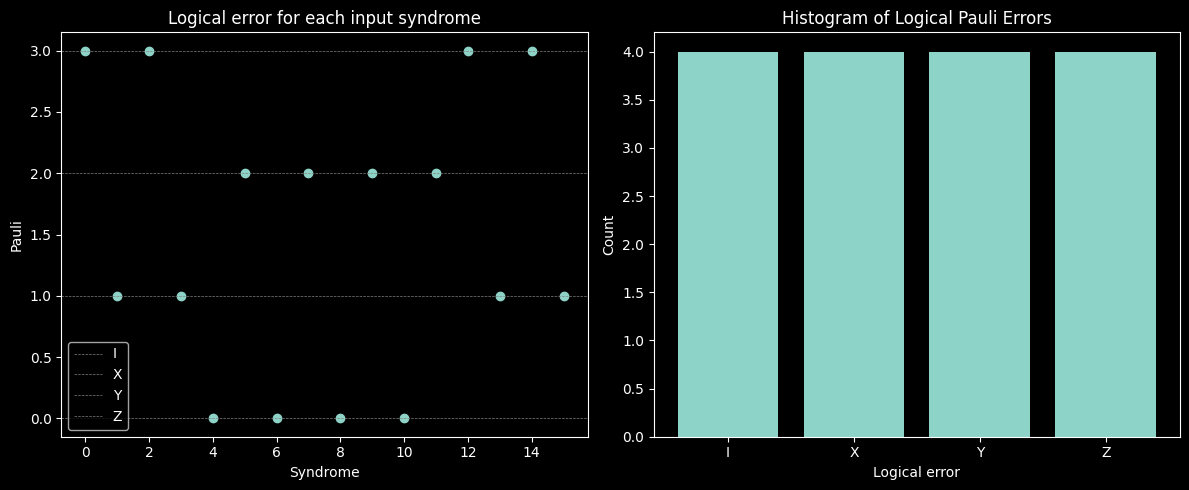

In [10]:
# Deterministic sweep: logical error for each syndrome given a fixed fault path
logical_error_dist_per_fault_path(code_513, fault_path=str_to_pauli(error), syndrome_error=syndrome_error)

## 5. Monte Carlo Simulation & Plots

Run `monte_carlo_new` for every input syndrome and visualise the logical error probability distribution.

The stacked bar chart shows P(X), P(Y), P(Z) for each input syndrome. P(I) = 1 - P(X) - P(Y) - P(Z) is the probability of no logical error (not plotted).

In [70]:
# --- Run MC for all syndromes ---
n_syn = code.n_syndromes
probs_new = np.zeros((n_syn, 4))

for s in range(n_syn):
    counts_L, _ = monte_carlo_new(code, p=p_val, q=q_val, s_in=s,
                                   n_samples=N_SAMPLES, seed=42 + s)
    probs_new[s] = counts_L / counts_L.sum()
    print(f's_in={s:2d}  P(I)={probs_new[s,0]:.6f}  P(X)={probs_new[s,1]:.6f}  '
          f'P(Y)={probs_new[s,2]:.6f}  P(Z)={probs_new[s,3]:.6f}')

s_in= 0  P(I)=0.501300  P(X)=0.166300  P(Y)=0.165050  P(Z)=0.167350
s_in= 1  P(I)=0.214600  P(X)=0.343800  P(Y)=0.250050  P(Z)=0.191550
s_in= 2  P(I)=0.215750  P(X)=0.185550  P(Y)=0.249800  P(Z)=0.348900
s_in= 3  P(I)=0.219100  P(X)=0.251250  P(Y)=0.342450  P(Z)=0.187200
s_in= 4  P(I)=0.214500  P(X)=0.185250  P(Y)=0.252750  P(Z)=0.347500
s_in= 5  P(I)=0.220900  P(X)=0.184900  P(Y)=0.342200  P(Z)=0.252000
s_in= 6  P(I)=0.322250  P(X)=0.239700  P(Y)=0.235400  P(Z)=0.202650
s_in= 7  P(I)=0.240350  P(X)=0.333150  P(Y)=0.181200  P(Z)=0.245300
s_in= 8  P(I)=0.214450  P(X)=0.348650  P(Y)=0.247800  P(Z)=0.189100
s_in= 9  P(I)=0.332150  P(X)=0.199400  P(Y)=0.235050  P(Z)=0.233400
s_in=10  P(I)=0.222250  P(X)=0.188300  P(Y)=0.344900  P(Z)=0.244550
s_in=11  P(I)=0.238850  P(X)=0.242400  P(Y)=0.179650  P(Z)=0.339100
s_in=12  P(I)=0.222150  P(X)=0.248600  P(Y)=0.343400  P(Z)=0.185850
s_in=13  P(I)=0.244500  P(X)=0.239450  P(Y)=0.175950  P(Z)=0.340100
s_in=14  P(I)=0.244000  P(X)=0.335100  P(Y)=0.17

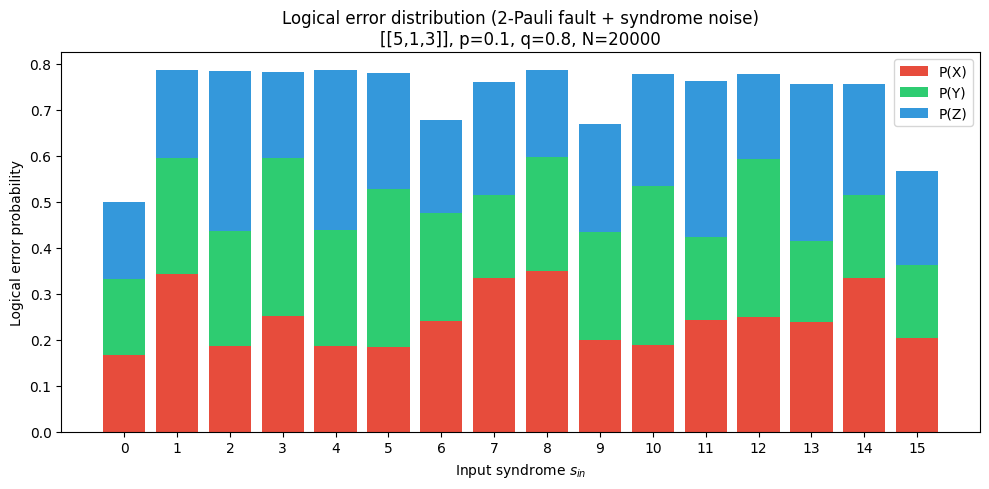


Average logical error rate across all syndromes: 0.731194


In [71]:
# --- Stacked bar chart: logical error probability per syndrome ---
import os

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_syn)

ax.bar(x, probs_new[:, 1], label='P(X)', color='#e74c3c')
ax.bar(x, probs_new[:, 2], bottom=probs_new[:, 1], label='P(Y)', color='#2ecc71')
ax.bar(x, probs_new[:, 3], bottom=probs_new[:, 1] + probs_new[:, 2],
       label='P(Z)', color='#3498db')

ax.set_xlabel('Input syndrome $s_{in}$')
ax.set_ylabel('Logical error probability')
ax.set_title(f'Logical error distribution (2-Pauli fault + syndrome noise)\n'
             f'{code.name}, p={p_val}, q={q_val}, N={N_SAMPLES}')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()

plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
fname    = (f"log_error_dist(2-pauli_syndrome_error)_{code_tag}_p={p_val}_q={q_val}_N={N_SAMPLES}.png")
fpath    = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')

plt.show()

# --- Summary ---
total_error_rate = 1 - probs_new[:, 0].mean()
print(f"\nAverage logical error rate across all syndromes: {total_error_rate:.6f}")

## 5b. Single-Syndrome Trace: Stacked P(X)/P(Y)/P(Z) vs q

For a **fixed input syndrome** `s_fixed`, sweep `q` and show how the logical-error populations `P(X), P(Y), P(Z)` evolve. Stacked bar chart — each bar is one `q`. Complementary to the averaged views in Sections 6–7.

Fixed input syndrome: s_in = 5
Code = [[5,1,3]], p = 0.1
q values = [0.         0.07142857 0.14285714 0.21428571 0.28571429 0.35714286
 0.42857143 0.5        0.57142857 0.64285714 0.71428571 0.78571429
 0.85714286 0.92857143 1.        ]
Samples per q: 50000

[1/15] q = 0.0000 ... P(I)=0.5000  P(X)=0.1698  P(Y)=0.1657  P(Z)=0.1645
[2/15] q = 0.0714 ... P(I)=0.4334  P(X)=0.2077  P(Y)=0.1871  P(Z)=0.1718
[3/15] q = 0.1429 ... P(I)=0.3866  P(X)=0.2322  P(Y)=0.2049  P(Z)=0.1763
[4/15] q = 0.2143 ... P(I)=0.3498  P(X)=0.2534  P(Y)=0.2129  P(Z)=0.1839
[5/15] q = 0.2857 ... P(I)=0.3199  P(X)=0.2623  P(Y)=0.2181  P(Z)=0.1997
[6/15] q = 0.3571 ... P(I)=0.2959  P(X)=0.2614  P(Y)=0.2276  P(Z)=0.2152
[7/15] q = 0.4286 ... P(I)=0.2781  P(X)=0.2525  P(Y)=0.2369  P(Z)=0.2324
[8/15] q = 0.5000 ... P(I)=0.2681  P(X)=0.2417  P(Y)=0.2458  P(Z)=0.2444
[9/15] q = 0.5714 ... P(I)=0.2577  P(X)=0.2336  P(Y)=0.2572  P(Z)=0.2516
[10/15] q = 0.6429 ... P(I)=0.2457  P(X)=0.2140  P(Y)=0.2803  P(Z)=0.2601
[11/15] q 

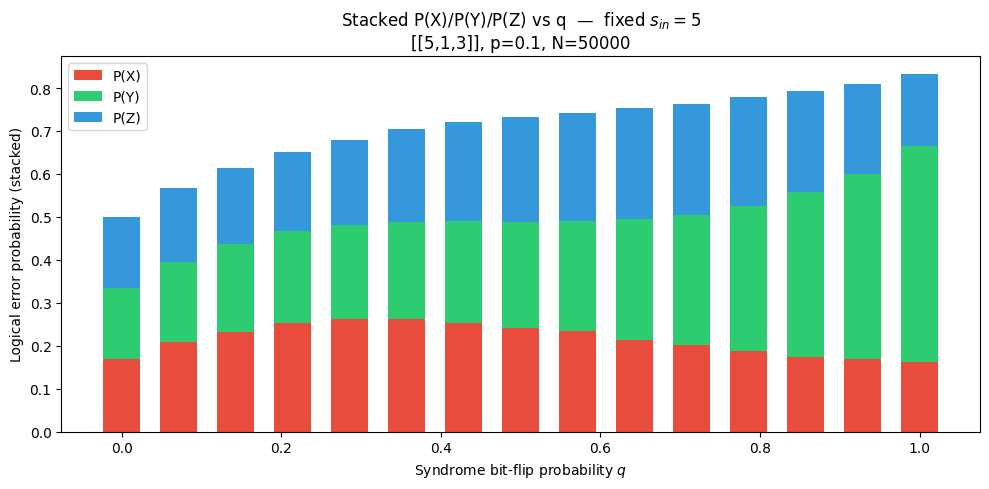

In [72]:
import os

# --- Fixed-syndrome q-sweep ---
s_fixed          = 5                      # <-- change to pick a different input syndrome
q_values_fixedS  = np.linspace(0, 1, 15)
N_SAMPLES_FIXEDS = 50_000

print(f"Fixed input syndrome: s_in = {s_fixed}")
print(f"Code = {code.name}, p = {p_val}")
print(f"q values = {q_values_fixedS}")
print(f"Samples per q: {N_SAMPLES_FIXEDS}")
print()

probs_vs_q = np.zeros((len(q_values_fixedS), 4))   # [iq, L] L=0..3 -> I,X,Y,Z

for iq, q in enumerate(q_values_fixedS):
    print(f"[{iq+1}/{len(q_values_fixedS)}] q = {q:.4f} ... ", end="", flush=True)
    counts_L, _ = monte_carlo_new(code, p=p_val, q=q, s_in=s_fixed,
                                  n_samples=N_SAMPLES_FIXEDS,
                                  seed=42 + iq)
    probs_vs_q[iq] = counts_L / counts_L.sum()
    print(f"P(I)={probs_vs_q[iq,0]:.4f}  P(X)={probs_vs_q[iq,1]:.4f}  "
          f"P(Y)={probs_vs_q[iq,2]:.4f}  P(Z)={probs_vs_q[iq,3]:.4f}")

print("\nPlotting...")

# --- Stacked bar chart: x = q, stacked P(X)+P(Y)+P(Z) ---
fig, ax = plt.subplots(figsize=(10, 5))
if len(q_values_fixedS) > 1:
    bar_width = (q_values_fixedS[-1] - q_values_fixedS[0]) / len(q_values_fixedS) * 0.7
else:
    bar_width = 0.1

ax.bar(q_values_fixedS, probs_vs_q[:, 1], width=bar_width,
       label='P(X)', color='#e74c3c')
ax.bar(q_values_fixedS, probs_vs_q[:, 2], width=bar_width,
       bottom=probs_vs_q[:, 1], label='P(Y)', color='#2ecc71')
ax.bar(q_values_fixedS, probs_vs_q[:, 3], width=bar_width,
       bottom=probs_vs_q[:, 1] + probs_vs_q[:, 2],
       label='P(Z)', color='#3498db')

ax.set_xlabel('Syndrome bit-flip probability $q$')
ax.set_ylabel('Logical error probability (stacked)')
ax.set_title(f'Stacked P(X)/P(Y)/P(Z) vs q  —  fixed $s_{{in}}={s_fixed}$\n'
             f'{code.name}, p={p_val}, N={N_SAMPLES_FIXEDS}')
ax.legend()
plt.tight_layout()

# --- Save ---
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)
code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
q_tag    = f"q{q_values_fixedS[0]:g}-to-{q_values_fixedS[-1]:g}-n{len(q_values_fixedS)}"
fname    = f"stackedPXYZ_vs_q__{code_tag}__sfixed{s_fixed}__p{p_val:g}__{q_tag}__N{N_SAMPLES_FIXEDS}.png"
fpath    = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")

plt.show()

## 6. Sweep over q: Spread & Average Logical Error Probability

For each `q` in a sweep, run the MC for every input syndrome and compute:

- **Spread** — for each syndrome, `sqrt( sum_{A in {X,Y,Z}} (P(A) - p_logical/3)^2 )`, where
  `p_logical = P(X)+P(Y)+P(Z)` and `p_logical/3` is the mean of `{P(X),P(Y),P(Z)}`.
  Measures non-uniformity among the three logical errors — larger spread means a tendency toward a specific logical error.
- **P(logical error)** — `p_logical = P(X)+P(Y)+P(Z)` per syndrome, then averaged.

Both are averaged over all input syndromes and plotted vs `q`. The figure is saved to `ECcode/plots/` with parameters encoded in the filename.

Sweep: 20 q-values x 16 syndromes x 10000 samples
Code=[[5,1,3]], p=0.1
q_values = [0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ]

[1/20] q = 0.0000 ... <spread>=0.011169 ± 0.005600, <P_logical>=0.484094 ± 0.066001
[2/20] q = 0.0526 ... <spread>=0.037939 ± 0.010053, <P_logical>=0.532600 ± 0.066414
[3/20] q = 0.1053 ... <spread>=0.054913 ± 0.014045, <P_logical>=0.575400 ± 0.066877
[4/20] q = 0.1579 ... <spread>=0.062305 ± 0.017947, <P_logical>=0.606950 ± 0.065856
[5/20] q = 0.2105 ... <spread>=0.062578 ± 0.017362, <P_logical>=0.634088 ± 0.065602
[6/20] q = 0.2632 ... <spread>=0.057116 ± 0.016334, <P_logical>=0.659994 ± 0.063468
[7/20] q = 0.3158 ... <spread>=0.047649 ± 0.016597, <P_logical>=0.678894 ± 0.062665
[8/20] q = 0.3684 ... <spread>=0.036168 ± 0.015523, <P_logical>=0.692475 ± 0.062719
[9/20] q = 0.4211 .

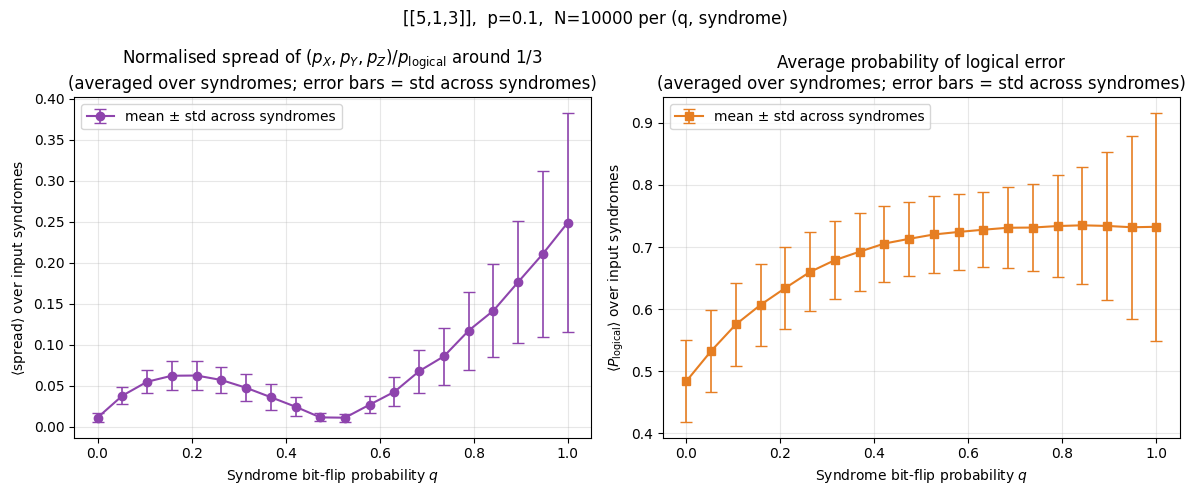

In [75]:
import os

# --- Sweep parameters ---
q_values         = np.linspace(0, 1, 20)
N_SAMPLES_SWEEP  = 10_000
n_syn            = code.n_syndromes

print(f"Sweep: {len(q_values)} q-values x {n_syn} syndromes x {N_SAMPLES_SWEEP} samples")
print(f"Code={code.name}, p={p_val}")
print(f"q_values = {q_values}")
print()

# Per-syndrome arrays stored for every q — reused by Section 6b (Cell B)
plogicals_all = np.zeros((len(q_values), n_syn))
spreads_all   = np.zeros((len(q_values), n_syn))

avg_spread   = np.zeros(len(q_values))
avg_plogical = np.zeros(len(q_values))
std_spread   = np.zeros(len(q_values))
std_plogical = np.zeros(len(q_values))

for iq, q in enumerate(q_values):
    print(f"[{iq+1}/{len(q_values)}] q = {q:.4f} ... ", end="", flush=True)
    for s in range(n_syn):
        counts_L, _ = monte_carlo_new(code, p=p_val, q=q, s_in=s,
                                      n_samples=N_SAMPLES_SWEEP,
                                      seed=42 + s + iq * 1000)
        probs = counts_L / counts_L.sum()
        pX, pY, pZ = probs[1], probs[2], probs[3]
        p_log      = pX + pY + pZ
        plogicals_all[iq, s] = p_log
        # Normalised spread: fractional deviation of (pX,pY,pZ)/p_log from 1/3.
        # Removes overall p_log magnitude, focusing purely on the X/Y/Z bias shape.
        if p_log > 0:
            fX, fY, fZ = pX / p_log, pY / p_log, pZ / p_log
            spreads_all[iq, s] = np.sqrt((fX - 1/3)**2
                                         + (fY - 1/3)**2
                                         + (fZ - 1/3)**2)
        else:
            spreads_all[iq, s] = np.nan   # undefined when no logical errors observed
    avg_spread[iq]   = np.nanmean(spreads_all[iq])
    std_spread[iq]   = np.nanstd(spreads_all[iq])
    avg_plogical[iq] = plogicals_all[iq].mean()
    std_plogical[iq] = plogicals_all[iq].std()
    print(f"<spread>={avg_spread[iq]:.6f} ± {std_spread[iq]:.6f}, "
          f"<P_logical>={avg_plogical[iq]:.6f} ± {std_plogical[iq]:.6f}")

print("\nSweep complete. Plotting...")

# --- Plot (error bars = std across the 16 syndromes) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(q_values, avg_spread, yerr=std_spread,
                 fmt='o-', color='#8e44ad', ecolor='#8e44ad',
                 capsize=4, elinewidth=1.2,
                 label='mean ± std across syndromes')
axes[0].set_xlabel('Syndrome bit-flip probability $q$')
axes[0].set_ylabel(r'$\langle$spread$\rangle$ over input syndromes')
axes[0].set_title('Normalised spread of $(p_X,p_Y,p_Z)/p_{\\mathrm{logical}}$ around 1/3\n'
                  '(averaged over syndromes; error bars = std across syndromes)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].errorbar(q_values, avg_plogical, yerr=std_plogical,
                 fmt='s-', color='#e67e22', ecolor='#e67e22',
                 capsize=4, elinewidth=1.2,
                 label='mean ± std across syndromes')
axes[1].set_xlabel('Syndrome bit-flip probability $q$')
axes[1].set_ylabel(r'$\langle P_{\mathrm{logical}}\rangle$ over input syndromes')
axes[1].set_title('Average probability of logical error\n'
                  '(averaged over syndromes; error bars = std across syndromes)')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f'{code.name},  p={p_val},  N={N_SAMPLES_SWEEP} per (q, syndrome)')
plt.tight_layout()

# --- Save ---
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
q_tag    = f"q{q_values[0]:g}-to-{q_values[-1]:g}-n{len(q_values)}"
fname    = f"spread_and_plogical_vs_q__{code_tag}__p{p_val:g}__{q_tag}__N{N_SAMPLES_SWEEP}.png"
fpath    = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")

plt.show()

In [74]:
print(np.sqrt(2/3))

0.816496580927726


## 6b. Across-Syndrome Variation vs q

Section 6 averages `p_logical` and `spread` **over** the 16 input syndromes. This section instead looks at **how much those per-syndrome values differ from each other** at each `q`. Reuses `plogicals_all` and `spreads_all` from Section 6 — run Section 6 first.

Four subplots in one figure (2×2):

| | std-vs-q (single line) | box plot (full per-syndrome distribution) |
|---|---|---|
| **Row 1 — `P_logical`** | **(A)** std of `P_logical` across syndromes | **(B)** box plot of `P_logical` across syndromes |
| **Row 2 — spread** | **(C)** std of per-syndrome spread across syndromes | **(D)** box plot of per-syndrome spread across syndromes |

- **Row 1 (A, B)** answers: *"do all syndromes have the same total logical-error rate, or do some fail more often?"*
- **Row 2 (C, D)** answers: *"do all syndromes have the same Pauli-type bias (X/Y/Z tilt), or do some syndromes favor one Pauli more strongly than others?"*

Across-syndrome std per q:
       q    std(P_logical)     std(spread)
  0.0000          0.066001        0.005600
  0.2000          0.065230        0.017836
  0.4000          0.062575        0.012176
  0.6000          0.060469        0.014563
  0.8000          0.080580        0.048377
  1.0000          0.182818        0.135135



<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ylee\AppData\Local\Temp\ipykernel_20760\3630534589.py:25: SyntaxWarning: invalid escape sequence '\m'
  axes[0, 0].set_title('(A)  ACROSS-SYNDROME std of  $P_{\mathrm{logical}}$  vs q\n'
C:\Users\ylee\AppData\Local\Temp\ipykernel_20760\3630534589.py:37: SyntaxWarning: invalid escape sequence '\m'
  axes[0, 1].set_title('(B)  DISTRIBUTION of per-syndrome  $P_{\mathrm{logical}}$  at each q\n'


Saved: plots\across-syndrome-variation_vs_q__5-1-3__p0.1__q0-to-1-n6__N10000.png


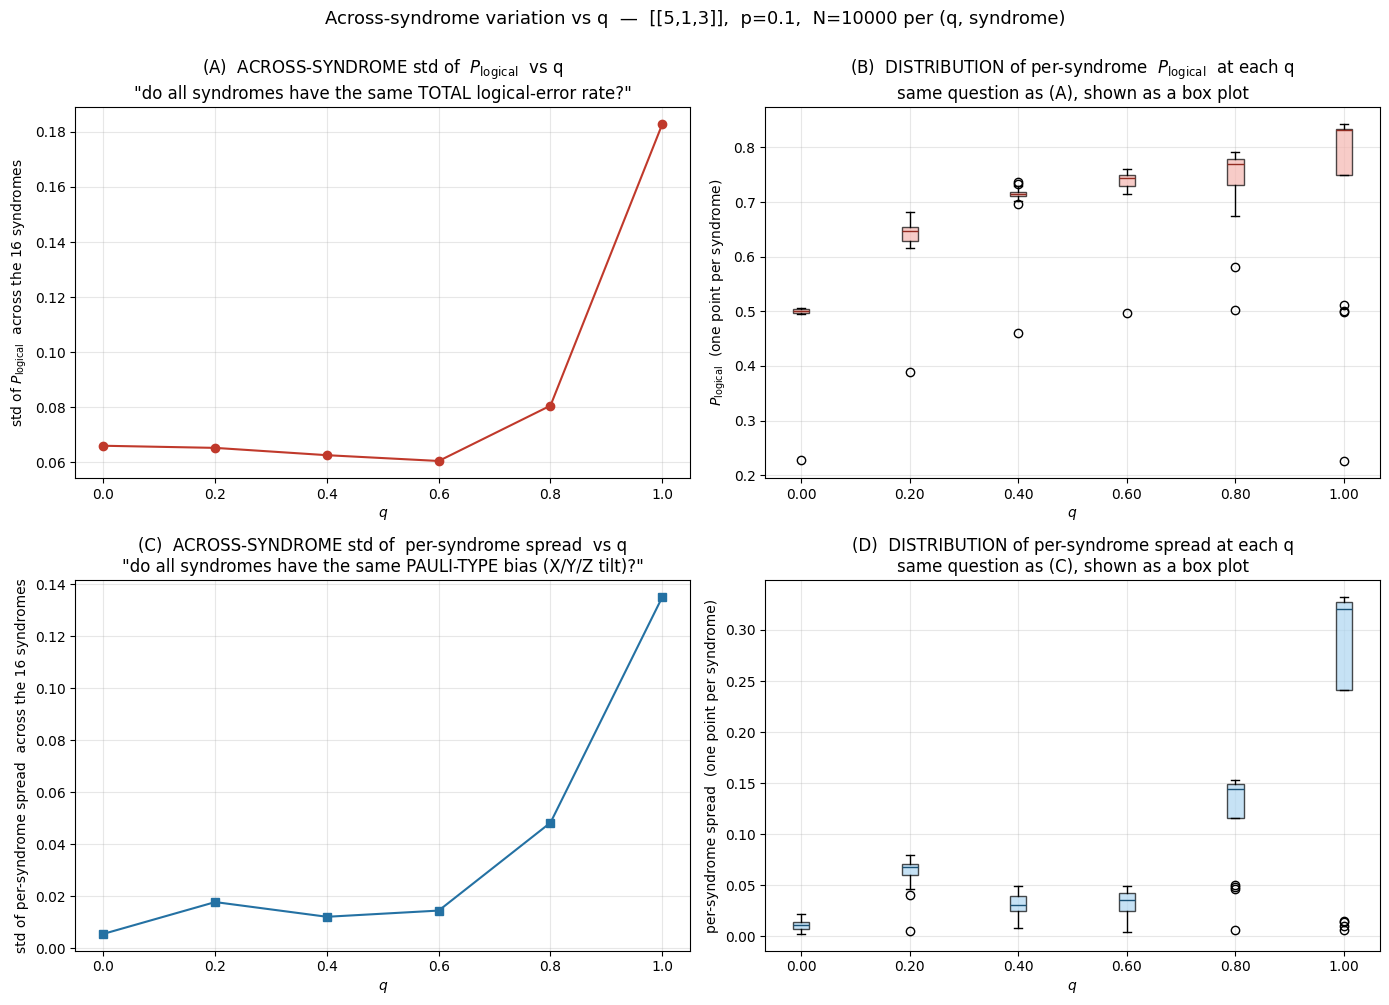

In [64]:
import os

# Requires: plogicals_all, spreads_all, q_values, N_SAMPLES_SWEEP from Section 6
std_plogical_across_syn = plogicals_all.std(axis=1)   # shape (n_q,)
std_spread_across_syn   = spreads_all.std(axis=1)     # shape (n_q,)

print("Across-syndrome std per q:")
print(f"{'q':>8}  {'std(P_logical)':>16}  {'std(spread)':>14}")
for iq, q in enumerate(q_values):
    print(f"{q:8.4f}  {std_plogical_across_syn[iq]:16.6f}  {std_spread_across_syn[iq]:14.6f}")
print()

# --- 2x2 figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if len(q_values) > 1:
    box_w = (q_values[1] - q_values[0]) * 0.15
else:
    box_w = 0.05

# (A) std of P_logical across syndromes vs q — top-left
axes[0, 0].plot(q_values, std_plogical_across_syn, 'o-', color='#c0392b')
axes[0, 0].set_xlabel('$q$')
axes[0, 0].set_ylabel(r'std of $P_{\mathrm{logical}}$  across the 16 syndromes')
axes[0, 0].set_title('(A)  ACROSS-SYNDROME std of  $P_{\mathrm{logical}}$  vs q\n'
                     '"do all syndromes have the same TOTAL logical-error rate?"')
axes[0, 0].grid(alpha=0.3)

# (B) box plot of P_logical across syndromes per q — top-right
axes[0, 1].boxplot([plogicals_all[iq] for iq in range(len(q_values))],
                   positions=q_values, widths=box_w, manage_ticks=False,
                   patch_artist=True,
                   boxprops=dict(facecolor='#f5b7b1', alpha=0.7),
                   medianprops=dict(color='#922b21'))
axes[0, 1].set_xlabel('$q$')
axes[0, 1].set_ylabel(r'$P_{\mathrm{logical}}$  (one point per syndrome)')
axes[0, 1].set_title('(B)  DISTRIBUTION of per-syndrome  $P_{\mathrm{logical}}$  at each q\n'
                     'same question as (A), shown as a box plot')
axes[0, 1].set_xticks(q_values)
axes[0, 1].set_xticklabels([f"{q:.2f}" for q in q_values])
axes[0, 1].grid(alpha=0.3)

# (C) std of per-syndrome spread across syndromes vs q — bottom-left
axes[1, 0].plot(q_values, std_spread_across_syn, 's-', color='#2471a3')
axes[1, 0].set_xlabel('$q$')
axes[1, 0].set_ylabel(r'std of per-syndrome spread  across the 16 syndromes')
axes[1, 0].set_title('(C)  ACROSS-SYNDROME std of  per-syndrome spread  vs q\n'
                     '"do all syndromes have the same PAULI-TYPE bias (X/Y/Z tilt)?"')
axes[1, 0].grid(alpha=0.3)

# (D) box plot of per-syndrome spread across syndromes per q — bottom-right
axes[1, 1].boxplot([spreads_all[iq] for iq in range(len(q_values))],
                   positions=q_values, widths=box_w, manage_ticks=False,
                   patch_artist=True,
                   boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                   medianprops=dict(color='#1a5276'))
axes[1, 1].set_xlabel('$q$')
axes[1, 1].set_ylabel('per-syndrome spread  (one point per syndrome)')
axes[1, 1].set_title('(D)  DISTRIBUTION of per-syndrome spread at each q\n'
                     'same question as (C), shown as a box plot')
axes[1, 1].set_xticks(q_values)
axes[1, 1].set_xticklabels([f"{q:.2f}" for q in q_values])
axes[1, 1].grid(alpha=0.3)

fig.suptitle(f'Across-syndrome variation vs q  —  {code.name},  p={p_val},  '
             f'N={N_SAMPLES_SWEEP} per (q, syndrome)',
             fontsize=13, y=1.00)
plt.tight_layout()

# --- Save ---
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)
code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
q_tag    = f"q{q_values[0]:g}-to-{q_values[-1]:g}-n{len(q_values)}"
fname    = f"across-syndrome-variation_vs_q__{code_tag}__p{p_val:g}__{q_tag}__N{N_SAMPLES_SWEEP}.png"
fpath    = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")

plt.show()

## 7. Sweep over p: Spread & Average Logical Error Probability

Same quantities as Section 6, but now we fix `q = q_val` and sweep over `p` (the single-qubit depolarizing rate). Saved to `ECcode/plots/` with `p`-range and fixed `q` encoded in the filename.

Sweep: 8 p-values x 16 syndromes x 10000 samples
Code=[[5,1,3]], q=1.0
p_values = [0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]

[1/8] p = 0.0000 ... <spread>=0.612372, <P_logical>=0.750000
[2/8] p = 0.1429 ... <spread>=0.125492, <P_logical>=0.733712
[3/8] p = 0.2857 ... <spread>=0.021532, <P_logical>=0.746375
[4/8] p = 0.4286 ... <spread>=0.006876, <P_logical>=0.747719
[5/8] p = 0.5714 ... <spread>=0.006000, <P_logical>=0.751106
[6/8] p = 0.7143 ... <spread>=0.005208, <P_logical>=0.749800
[7/8] p = 0.8571 ... <spread>=0.003895, <P_logical>=0.750456
[8/8] p = 1.0000 ... <spread>=0.006983, <P_logical>=0.750287

Sweep complete. Plotting...
Saved: plots\spread_and_plogical_vs_p__5-1-3__q1__p0-to-1-n8__N10000.png


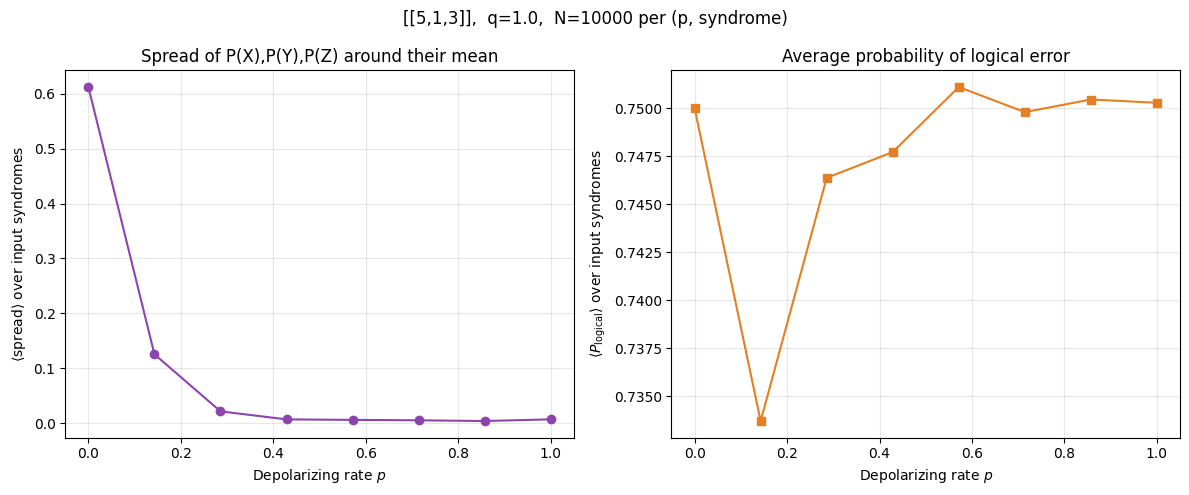

In [14]:
import os

# --- Sweep parameters ---
p_values         = np.linspace(0, 1, 8)
q_val = 1.0
N_SAMPLES_SWEEP  = 10_000
n_syn            = code.n_syndromes

print(f"Sweep: {len(p_values)} p-values x {n_syn} syndromes x {N_SAMPLES_SWEEP} samples")
print(f"Code={code.name}, q={q_val}")
print(f"p_values = {p_values}")
print()

avg_spread_p   = np.zeros(len(p_values))
avg_plogical_p = np.zeros(len(p_values))

for ip, p in enumerate(p_values):
    print(f"[{ip+1}/{len(p_values)}] p = {p:.4f} ... ", end="", flush=True)
    spreads   = np.zeros(n_syn)
    plogicals = np.zeros(n_syn)
    for s in range(n_syn):
        counts_L, _ = monte_carlo_new(code, p=p, q=q_val, s_in=s,
                                      n_samples=N_SAMPLES_SWEEP,
                                      seed=42 + s + ip * 1000)
        probs = counts_L / counts_L.sum()
        pX, pY, pZ   = probs[1], probs[2], probs[3]
        p_log        = pX + pY + pZ
        mean_xyz     = p_log / 3.0
        spreads[s]   = np.sqrt((pX - mean_xyz)**2
                               + (pY - mean_xyz)**2
                               + (pZ - mean_xyz)**2)
        plogicals[s] = p_log
    avg_spread_p[ip]   = spreads.mean()
    avg_plogical_p[ip] = plogicals.mean()
    print(f"<spread>={avg_spread_p[ip]:.6f}, <P_logical>={avg_plogical_p[ip]:.6f}")

print("\nSweep complete. Plotting...")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(p_values, avg_spread_p, 'o-', color='#8e44ad')
axes[0].set_xlabel('Depolarizing rate $p$')
axes[0].set_ylabel(r'$\langle$spread$\rangle$ over input syndromes')
axes[0].set_title('Spread of P(X),P(Y),P(Z) around their mean')
axes[0].grid(alpha=0.3)

axes[1].plot(p_values, avg_plogical_p, 's-', color='#e67e22')
axes[1].set_xlabel('Depolarizing rate $p$')
axes[1].set_ylabel(r'$\langle P_{\mathrm{logical}}\rangle$ over input syndromes')
axes[1].set_title('Average probability of logical error')
axes[1].grid(alpha=0.3)

fig.suptitle(f'{code.name},  q={q_val},  N={N_SAMPLES_SWEEP} per (p, syndrome)')
plt.tight_layout()

# --- Save ---
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)

code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
p_tag    = f"p{p_values[0]:g}-to-{p_values[-1]:g}-n{len(p_values)}"
fname    = f"spread_and_plogical_vs_p__{code_tag}__q{q_val:g}__{p_tag}__N{N_SAMPLES_SWEEP}.png"
fpath    = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"Saved: {fpath}")

plt.show()

## 8. Transfer Matrix A: P(s_j | s_i)

Build a `(n_syn × n_syn)` stochastic matrix where entry `A[i, j] = P(s_j | s_i)` is the probability that the output syndrome is `s_j` given that the input syndrome was `s_i`.

For each input syndrome `s_i`, we run `monte_carlo_new` and use the returned `counts_sout` (already accumulated by the MC engine) to fill row `i` of the matrix. Each row is a probability distribution over output syndromes and sums to 1.

Building transfer matrix for [[5,1,3]]
p=0, q=0.4, N=100000
Matrix shape: (16 x 16)

s_in= 0  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1301
s_in= 1  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1293
s_in= 2  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1291
s_in= 3  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1301
s_in= 4  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1287
s_in= 5  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1300
s_in= 6  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1308
s_in= 7  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1310
s_in= 8  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1312
s_in= 9  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1280
s_in=10  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1280
s_in=11  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1314
s_in=12  row sum=1.000000  argmax(s_out)= 0  P(s_out=argmax)=0.1291
s_in=13  row sum=1.000000  argm

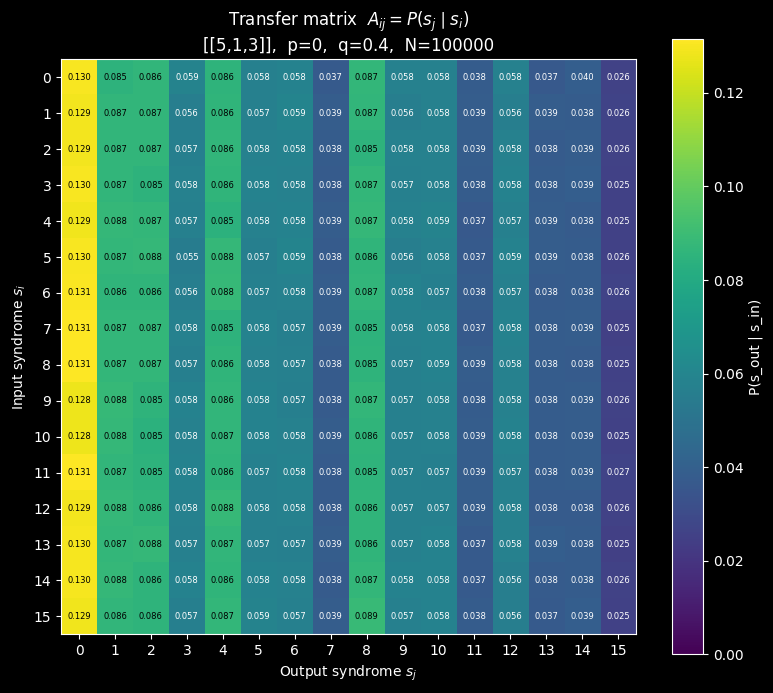

In [16]:
import os

# --- Parameters ---
p_val = 0
q_val = 0.4
N_SAMPLES_TM = 100_000
n_syn = code.n_syndromes

print(f"Building transfer matrix for {code.name}")
print(f"p={p_val}, q={q_val}, N={N_SAMPLES_TM}")
print(f"Matrix shape: ({n_syn} x {n_syn})")
print()

# --- Build transfer matrix ---
A = np.zeros((n_syn, n_syn))

for s_i in range(n_syn):
    _, counts_sout = monte_carlo_new(code, p=p_val, q=q_val, s_in=s_i,
                                     n_samples=N_SAMPLES_TM, seed=42 + s_i)
    A[s_i] = counts_sout / counts_sout.sum()
    print(f"s_in={s_i:2d}  row sum={A[s_i].sum():.6f}  "
          f"argmax(s_out)={A[s_i].argmax():2d}  P(s_out=argmax)={A[s_i].max():.4f}")

print("\nRow sums (should all be ≈ 1.0):", np.round(A.sum(axis=1), 6))

# --- Heatmap ---
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(A, vmin=0, vmax=A.max(), cmap='viridis')
plt.colorbar(im, ax=ax, label='P(s_out | s_in)')

ax.set_xlabel('Output syndrome $s_j$')
ax.set_ylabel('Input syndrome $s_i$')
ax.set_title(f'Transfer matrix  $A_{{ij}} = P(s_j \\mid s_i)$\n'
             f'{code.name},  p={p_val},  q={q_val},  N={N_SAMPLES_TM}')
ax.set_xticks(range(n_syn))
ax.set_yticks(range(n_syn))

# Annotate cells with probability values
for i in range(n_syn):
    for j in range(n_syn):
        val = A[i, j]
        text_color = 'white' if val < A.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=6, color=text_color)

plt.tight_layout()

# --- Save ---
plots_dir = 'plots'
os.makedirs(plots_dir, exist_ok=True)
code_tag = code.name.replace('[', '').replace(']', '').replace(',', '-')
fname = f"transfer_matrix__{code_tag}__p{p_val:g}__q{q_val:g}__N{N_SAMPLES_TM}.png"
fpath = os.path.join(plots_dir, fname)
fig.savefig(fpath, dpi=150, bbox_inches='tight')
print(f"\nSaved: {fpath}")

plt.show()